# Frozen Phonon CBED — Si [111]

Frozen phonon averaged CBED patterns for Si [111] zone axis (200 keV),
comparing all 4 propagation methods against KG FWD Lanczos ground truth.

- **Methods**: Fresnel MS, Angular Spectrum MS, WPM, KG FWD Lanczos (ground truth)
- **Frozen phonons**: 16 configurations, σ_Si = 0.078 Å
- **Probe**: 6.2 mrad convergent beam
- **Crystal**: Si [111] from Si.cif, 120 unit cells along beam, 16 slices/cell
- **Metric**: Relative L2 error of frozen-phonon-averaged CBED pattern vs KG FWD Lanczos

In [1]:
%matplotlib inline

import os
from time import perf_counter
import functools

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".4"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import ase.io
from matplotlib.colors import LogNorm
from tqdm.auto import tqdm

from wide_angle_propagation.propagation_methods import (
    electron_refractive_index,
    energy2wavelength,
    fresnel_propagation_kernel,
    angular_spectrum_propagation_kernel,
    simulate_fresnel_as,
    simulate_wpm,
    simulate_wpm_jit,
 )
from wide_angle_propagation.propagation_methods import _lanczos_expsqrt

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

## Crystal, probe, and potential setup

Si [111] zone axis from Si.cif → rotation → orthogonalisation.
6.2 mrad convergent probe, 200 keV, 32 frozen phonon configurations.

In [2]:
# --- Runtime mode ---
quick_run = True  # Set False for full-resolution benchmark run
if quick_run:
    n_cells_xy = (3, 2)
    n_cells_z = 24
    n_slices_per_cell = 4
    n_fp = 2
    lanczos_m = 24
    run_wpm = False
else:
    n_cells_xy = (6, 4)
    n_cells_z = 120
    n_slices_per_cell = 16
    n_fp = 16
    lanczos_m = 80
    run_wpm = True

# --- Parameters ---
energy = 200e3
sigma_Si = 0.078
semiangle_mrad = 6.2

# --- Build Si [111] orthogonal cell ---
silicon = ase.io.read(os.path.join("..", "data", "Si.cif"))
silicon_111 = silicon.copy()
silicon_111.rotate((0, 0, 1), (1, 1, 1), rotate_cell=True)
silicon_111.rotate(45, "z", rotate_cell=True)
unit_cell = abtem.orthogonalize_cell(silicon_111)

supercell = unit_cell * (*n_cells_xy, n_cells_z)

cell_thickness = float(unit_cell.cell[2, 2])
slice_dz = cell_thickness / n_slices_per_cell
total_thickness = n_cells_z * cell_thickness
n_total_slices = n_cells_z * n_slices_per_cell

# Reference potential (for grid matching)
potential_ref = abtem.Potential(
    supercell, sampling=0.1, slice_thickness=slice_dz,
    projection="finite", parametrization="lobato",
)
gpts = tuple(potential_ref.gpts)

# CBED probe
probe = abtem.Probe(energy=energy, semiangle_cutoff=semiangle_mrad)
probe.grid.match(potential_ref)
probe_array = jnp.array(cupy.asnumpy(probe.build(lazy=False).array))
sampling = (float(probe.grid.sampling[0]), float(probe.grid.sampling[1]))

# Propagation kernels
fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=slice_dz, energy=energy))
ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=slice_dz, energy=energy))

wavelength = energy2wavelength(energy)
print(f"Mode: {'quick' if quick_run else 'full'}")
print(f"Crystal: Si [111] (orthogonalised from Si.cif)")
print(f"Supercell: {n_cells_xy[0]}×{n_cells_xy[1]}×{n_cells_z}, {len(supercell)} atoms")
lx, ly, lz = supercell.cell.lengths()
print(f"Cell: {lx:.1f} × {ly:.1f} × {lz:.1f} Å")
print(f"Energy: {energy/1e3:.0f} keV, λ = {wavelength:.4f} Å")
print(f"Grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")
print(f"Slices: {n_total_slices} total ({n_slices_per_cell}/cell), dz = {slice_dz:.4f} Å")
print(f"Total thickness: {total_thickness:.1f} Å")
print(f"CBED probe: {semiangle_mrad} mrad")
print(f"Frozen phonons: {n_fp} configs, σ = {sigma_Si} Å")
print(f"Lanczos Krylov order m: {lanczos_m}")
print(f"Run WPM: {run_wpm}")

Mode: quick
Crystal: Si [111] (orthogonalised from Si.cif)
Supercell: 3×2×24, 6912 atoms
Cell: 23.1 × 26.7 × 226.3 Å
Energy: 200 keV, λ = 0.0251 Å
Grid: (231, 267), sampling = (0.1000, 0.0999) Å
Slices: 96 total (4/cell), dz = 2.3572 Å
Total thickness: 226.3 Å
CBED probe: 6.2 mrad
Frozen phonons: 2 configs, σ = 0.078 Å
Lanczos Krylov order m: 24
Run WPM: False


## KG FWD Lanczos propagator (lightweight runtime mode)

Uses a simple Python slice loop to avoid heavy first-time JIT compilation.
This is typically faster for interactive notebook reruns and parameter tuning.

In [3]:
def simulate_kg_fwd_lanczos(pot_arr, psi_0, dz, E, samp, lanczos_m=48):
    """Non-jitted KG forward Lanczos propagation with a Python loop."""
    ny, nx = psi_0.shape
    k0_sq = (2 * jnp.pi / energy2wavelength(E)) ** 2
    dy, dx = samp
    fy = jnp.fft.fftfreq(ny, d=dy)
    fx = jnp.fft.fftfreq(nx, d=dx)
    Fx, Fy = jnp.meshgrid(fx, fy)
    kp_sq = (2 * jnp.pi * Fy) ** 2 + (2 * jnp.pi * Fx) ** 2
    n_sq_all = jax.vmap(lambda V: electron_refractive_index(V, E) ** 2)(pot_arr)

    state = jnp.fft.fft2(jnp.asarray(psi_0, dtype=jnp.complex128)).ravel() / (ny * nx)
    for n_sq in n_sq_all:
        n_sq = n_sq.reshape(ny, nx)

        def matvec(v):
            vg = v.reshape(ny, nx)
            conv = jnp.fft.fft2(n_sq * jnp.fft.ifft2(vg))
            return (k0_sq * conv - kp_sq * vg).ravel()

        state = _lanczos_expsqrt(matvec, state, dz, lanczos_m)

    exit_k = state.reshape(ny, nx)
    exit_wave = jnp.fft.ifft2(exit_k) * (ny * nx)
    return np.asarray(exit_wave)

print("Lanczos propagator defined (non-jitted Python loop).")

Lanczos propagator defined (non-jitted Python loop).


## Frozen phonon propagation (quick mode friendly)

Each configuration: displace atoms thermally, build potential, run selected methods,
accumulate |DP|² for averaging. In quick mode, WPM is optional for faster turnaround.

In [4]:
method_names = ["Fresnel MS", "Angular Spectrum", "KG FWD Lanczos"]
if run_wpm:
    method_names.insert(2, "WPM")

dp_avg = {name: np.zeros(gpts) for name in method_names}
exit_waves = {}
method_timings = {name: 0.0 for name in method_names}

rng = np.random.default_rng(42)

for fp_idx in tqdm(range(n_fp), desc="Frozen phonon configs"):
    displaced = supercell.copy()
    displaced.positions += rng.normal(0, sigma_Si, displaced.positions.shape)
    displaced.wrap()
    displaced.info["thermal_sigma"] = 0.0
    displaced.arrays["thermal_sigma"] = np.zeros(len(displaced))

    pot_fp = abtem.Potential(
        displaced, gpts=gpts, slice_thickness=slice_dz,
        projection="finite", parametrization="lobato",
    )
    pot_arr = jnp.array(cupy.asnumpy(pot_fp.build(lazy=False).array / slice_dz))
    del pot_fp
    cupy.get_default_memory_pool().free_all_blocks()

    # Fresnel MS
    t0 = perf_counter()
    ew_f, _, _ = simulate_fresnel_as(pot_arr, probe_array, fk, slice_dz, energy)
    method_timings["Fresnel MS"] += perf_counter() - t0

    # Angular Spectrum MS
    t0 = perf_counter()
    ew_a, _, _ = simulate_fresnel_as(pot_arr, probe_array, ak, slice_dz, energy)
    method_timings["Angular Spectrum"] += perf_counter() - t0

    method_results = {
        "Fresnel MS": ew_f,
        "Angular Spectrum": ew_a,
    }

    # WPM (optional in quick mode)
    if run_wpm:
        t0 = perf_counter()
        if quick_run:
            ew_w, _, _ = simulate_wpm(pot_arr, probe_array, slice_dz, energy, sampling)
        else:
            ew_w, _, _ = simulate_wpm_jit(pot_arr, probe_array, slice_dz, energy, sampling)
        method_timings["WPM"] += perf_counter() - t0
        method_results["WPM"] = ew_w

    # KG FWD Lanczos (non-jitted)
    t0 = perf_counter()
    ew_l = simulate_kg_fwd_lanczos(
        pot_arr, probe_array, slice_dz, energy, sampling, lanczos_m=lanczos_m
    )
    method_timings["KG FWD Lanczos"] += perf_counter() - t0
    method_results["KG FWD Lanczos"] = ew_l

    # Accumulate |DP|²
    for name in method_names:
        ew = method_results[name]
        dp_i = np.abs(np.fft.fftshift(np.fft.fft2(np.asarray(ew)))) ** 2
        dp_avg[name] += dp_i / n_fp

    if fp_idx == n_fp - 1:
        exit_waves = {name: np.asarray(method_results[name]) for name in method_names}

    del pot_arr
    print(f"  Config {fp_idx + 1}/{n_fp} done.")

print(f"\nFrozen phonon averaging complete ({n_fp} configs × {len(method_names)} methods).")
print(f"\nTotal timings:")
for name in method_names:
    print(f"  {name:<22s} {method_timings[name]:>8.1f}s ({method_timings[name]/n_fp:.1f}s/config)")

Frozen phonon configs:   0%|          | 0/2 [00:00<?, ?it/s]

  Config 1/2 done.
  Config 2/2 done.

Frozen phonon averaging complete (2 configs × 3 methods).

Total timings:
  Fresnel MS                  1.7s (0.8s/config)
  Angular Spectrum            0.6s (0.3s/config)
  KG FWD Lanczos             72.8s (36.4s/config)


## CBED patterns (frozen phonon averaged)

Diffraction intensities averaged over all frozen phonon configurations.
Displayed on a log scale.

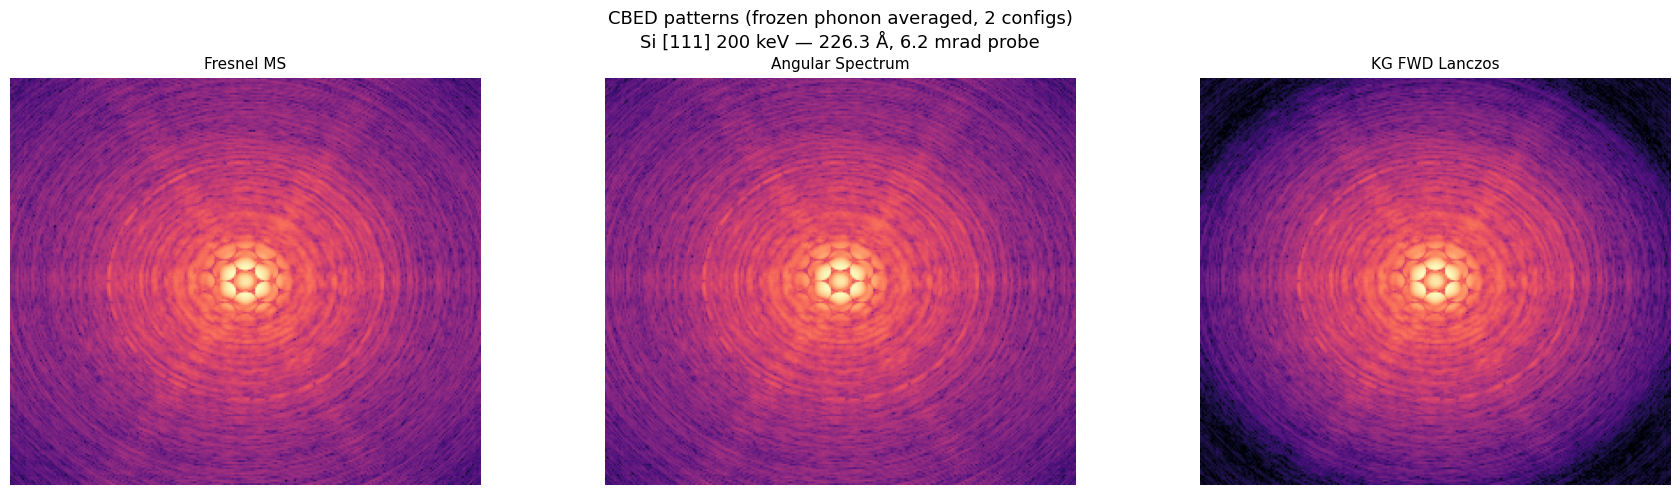

In [5]:
fig, axes = plt.subplots(1, len(method_names), figsize=(6 * len(method_names), 5))

for j, name in enumerate(method_names):
    dp = dp_avg[name]
    dp_n = dp / dp.max() if dp.max() > 0 else dp
    axes[j].imshow(dp_n, norm=LogNorm(vmin=1e-8, vmax=1), cmap="magma", origin="lower")
    axes[j].set_title(name, fontsize=11)
    axes[j].axis("off")

fig.suptitle(
    f"CBED patterns (frozen phonon averaged, {n_fp} configs)\n"
    f"Si [111] {energy/1e3:.0f} keV — {total_thickness:.1f} Å, {semiangle_mrad} mrad probe",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## Exit wave comparison (last frozen phonon configuration)

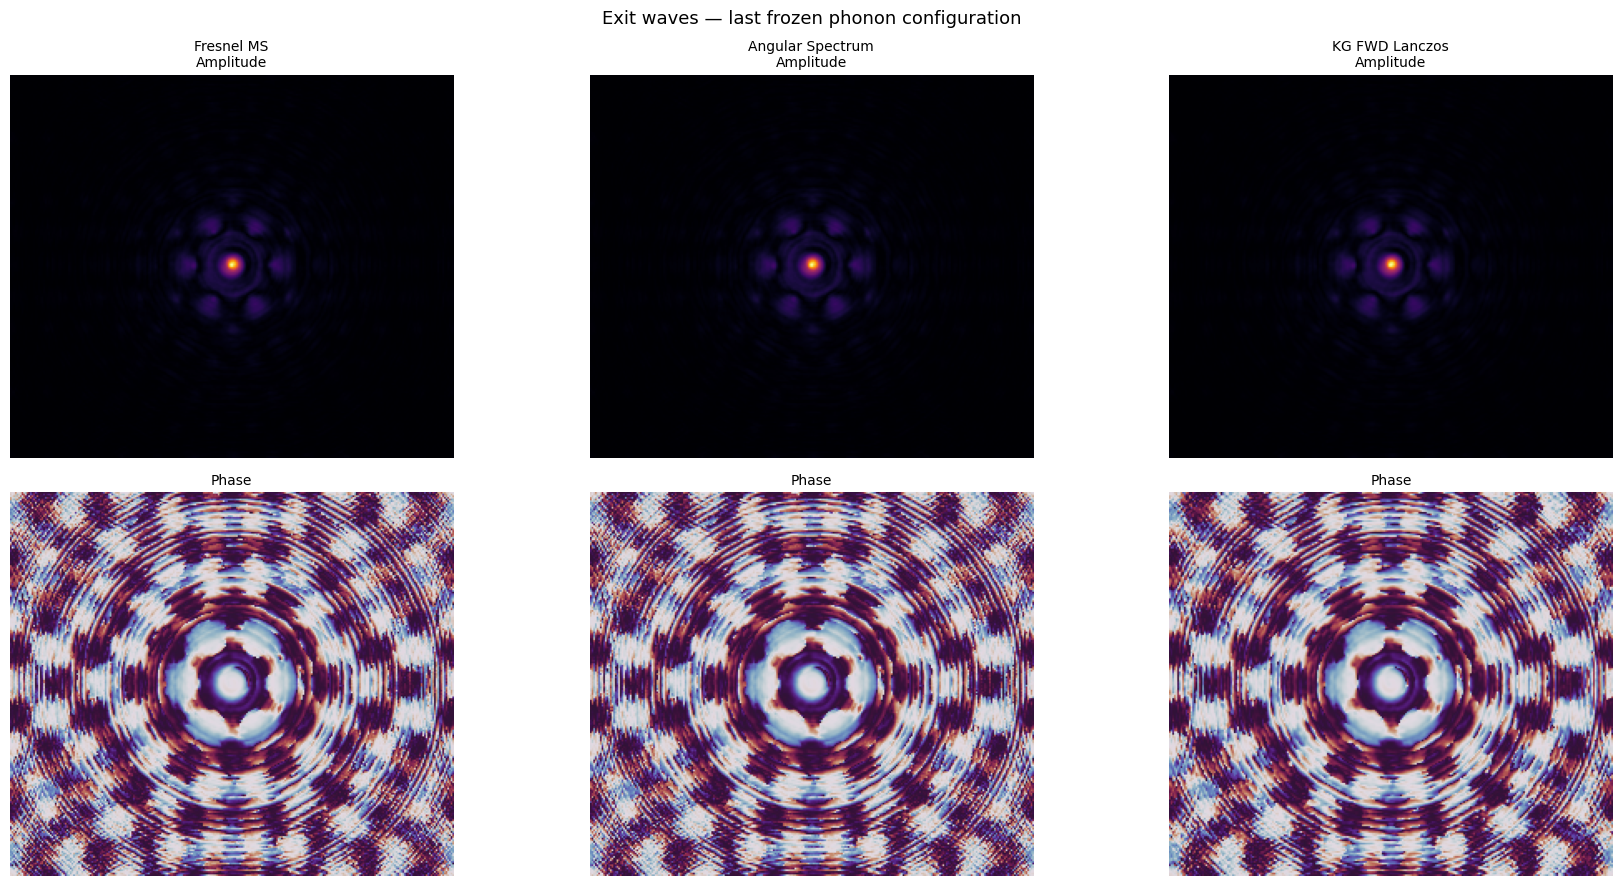

In [6]:
# Show amplitude and phase of the last frozen-phonon exit wave for each method
fig, axes = plt.subplots(2, len(method_names), figsize=(6 * len(method_names), 9))

for j, name in enumerate(method_names):
    ew = exit_waves[name]
    amp = np.abs(ew)
    phase = np.angle(ew)

    axes[0, j].imshow(amp, cmap="inferno", origin="lower")
    axes[0, j].set_title(f"{name}\nAmplitude", fontsize=10)
    axes[0, j].axis("off")

    im = axes[1, j].imshow(phase, cmap="twilight", origin="lower", vmin=-np.pi, vmax=np.pi)
    axes[1, j].set_title("Phase", fontsize=10)
    axes[1, j].axis("off")

fig.suptitle("Exit waves — last frozen phonon configuration", fontsize=13)
plt.tight_layout()
plt.show()

## Error analysis relative to KG FWD Lanczos

Difference maps of the FP-averaged diffraction patterns, plus RMSE and relative $L^2$ error.

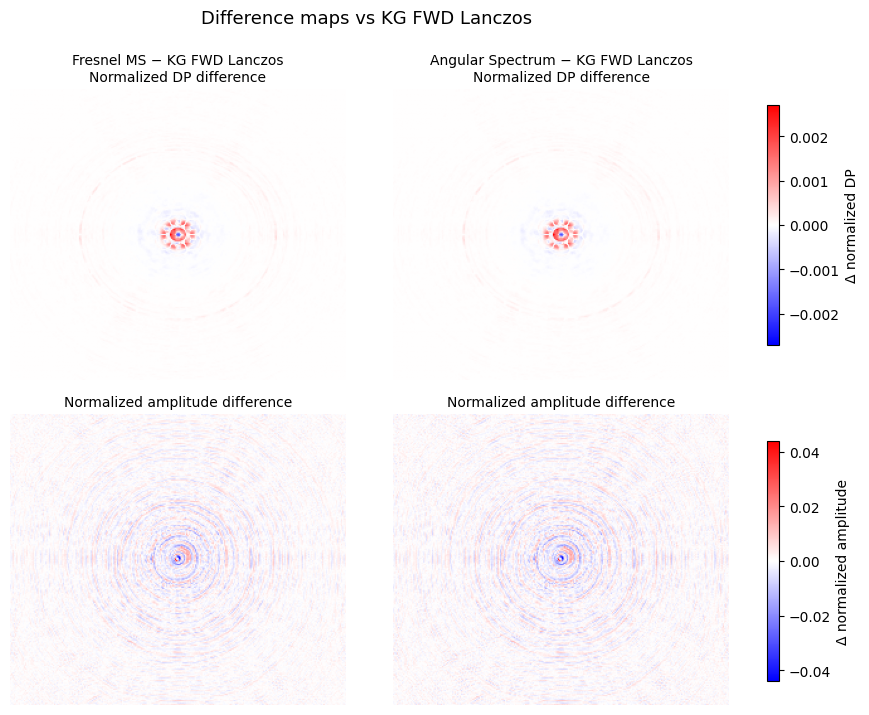


Method                            RMSE       Rel L2  Mean time (s)
-----------------------------------------------------------------
Fresnel MS                8.258233e-05 2.389151e-03           0.83
Angular Spectrum          8.305822e-05 2.402918e-03           0.28
KG FWD Lanczos (ref)      0.000000e+00 0.000000e+00          36.40


In [ ]:
ref_name = "KG FWD Lanczos"

# --- Reference normalizations ---
dp_ref = dp_avg[ref_name]
dp_ref_norm = dp_ref / dp_ref.max() if dp_ref.max() > 0 else dp_ref

amp_ref = np.abs(exit_waves[ref_name])
amp_ref_norm = amp_ref / amp_ref.max() if amp_ref.max() > 0 else amp_ref

compare_names = [n for n in method_names if n != ref_name]

# --- Precompute normalized differences ---
dp_diffs, amp_diffs = [], []
for name in compare_names:
    dp_n = dp_avg[name] / dp_avg[name].max() if dp_avg[name].max() > 0 else dp_avg[name]
    amp_n = np.abs(exit_waves[name])
    amp_n = amp_n / amp_n.max() if amp_n.max() > 0 else amp_n

    dp_diffs.append(dp_n - dp_ref_norm)
    amp_diffs.append(amp_n - amp_ref_norm)

dp_vlim = max(max(abs(d.min()), abs(d.max())) for d in dp_diffs)
amp_vlim = max(max(abs(d.min()), abs(d.max())) for d in amp_diffs)
dp_vlim = max(dp_vlim, 1e-6)
amp_vlim = max(amp_vlim, 1e-6)

# --- Difference maps: DP + amplitude ---
fig, axes = plt.subplots(2, len(compare_names), figsize=(5 * len(compare_names), 8))
if len(compare_names) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

im_dp = im_amp = None
for j, name in enumerate(compare_names):
    im_dp = axes[0, j].imshow(
        dp_diffs[j], cmap="bwr", origin="lower", vmin=-dp_vlim, vmax=dp_vlim
    )
    axes[0, j].set_title(f"{name} − {ref_name}\nNormalized DP Amplitude difference", fontsize=10)
    axes[0, j].axis("off")

    im_amp = axes[1, j].imshow(
        amp_diffs[j], cmap="bwr", origin="lower", vmin=-amp_vlim, vmax=amp_vlim
    )
    axes[1, j].set_title("Normalized amplitude difference", fontsize=10)
    axes[1, j].axis("off")

# Move images closer together
fig.subplots_adjust(right=0.88, wspace=0.03, hspace=0.12)

# Shared colorbars (one per row)
cax1 = fig.add_axes([0.90, 0.56, 0.012, 0.30])
cbar1 = fig.colorbar(im_dp, cax=cax1)
cbar1.set_label("Δ normalized DP")

cax2 = fig.add_axes([0.90, 0.14, 0.012, 0.30])
cbar2 = fig.colorbar(im_amp, cax=cax2)
cbar2.set_label("Δ normalized amplitude")

fig.suptitle("Difference maps vs KG FWD Lanczos", fontsize=13)
plt.show()

# --- Error table (DP-based, unchanged metric) ---
print(f"\n{'Method':<25} {'RMSE':>12} {'Rel L2':>12} {'Mean time (s)':>14}")
print("-" * 65)
for name in method_names:
    dp_n = dp_avg[name] / dp_avg[name].max() if dp_avg[name].max() > 0 else dp_avg[name]
    diff = dp_n - dp_ref_norm
    rmse = float(np.sqrt(np.mean(diff**2)))
    rel_l2 = float(np.linalg.norm(diff) / (np.linalg.norm(dp_ref_norm) + 1e-30))
    mean_t = method_timings[name] / n_fp
    marker = " (ref)" if name == ref_name else ""
    print(f"{name + marker:<25} {rmse:>12.6e} {rel_l2:>12.6e} {mean_t:>14.2f}")

## Timing benchmark

Wall-clock time per frozen phonon configuration, broken down by method.

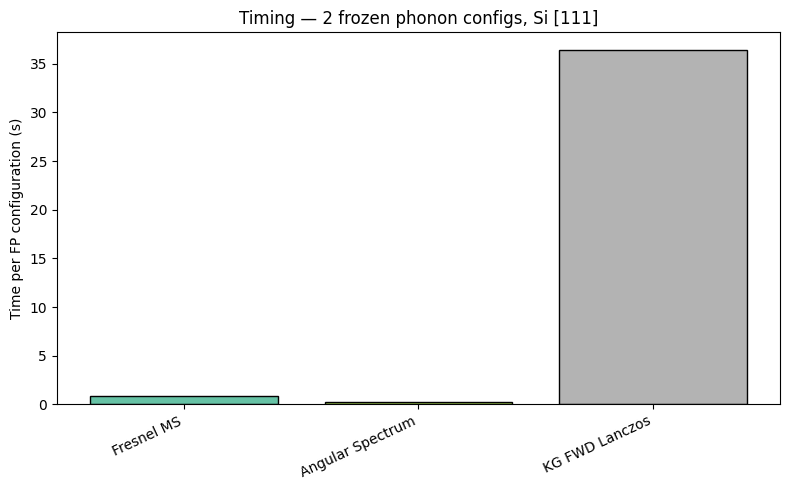


Total wall-clock times:
  Fresnel MS                     1.7 s
  Angular Spectrum               0.6 s
  KG FWD Lanczos                72.8 s


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
means = [method_timings[n] / n_fp for n in method_names]
colors = plt.cm.Set2(np.linspace(0, 1, len(method_names)))
bars = ax.bar(method_names, means, color=colors, edgecolor="k")
ax.set_ylabel("Time per FP configuration (s)")
ax.set_title(f"Timing — {n_fp} frozen phonon configs, Si [111]")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# Total wall-clock
print("\nTotal wall-clock times:")
for name in method_names:
    print(f"  {name:<25} {method_timings[name]:>8.1f} s")